📊 Generating evaluation results...


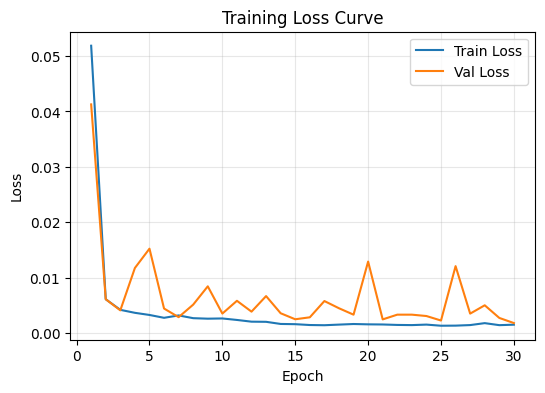

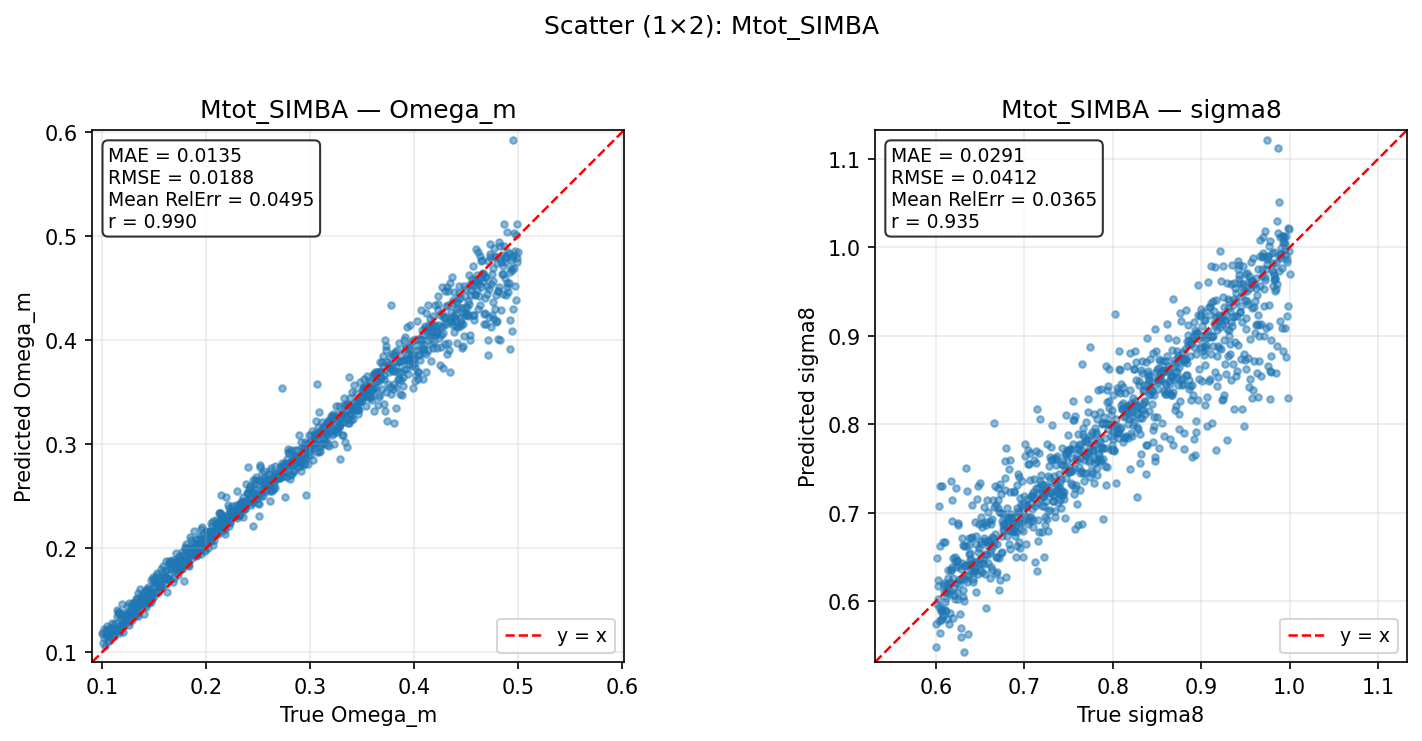

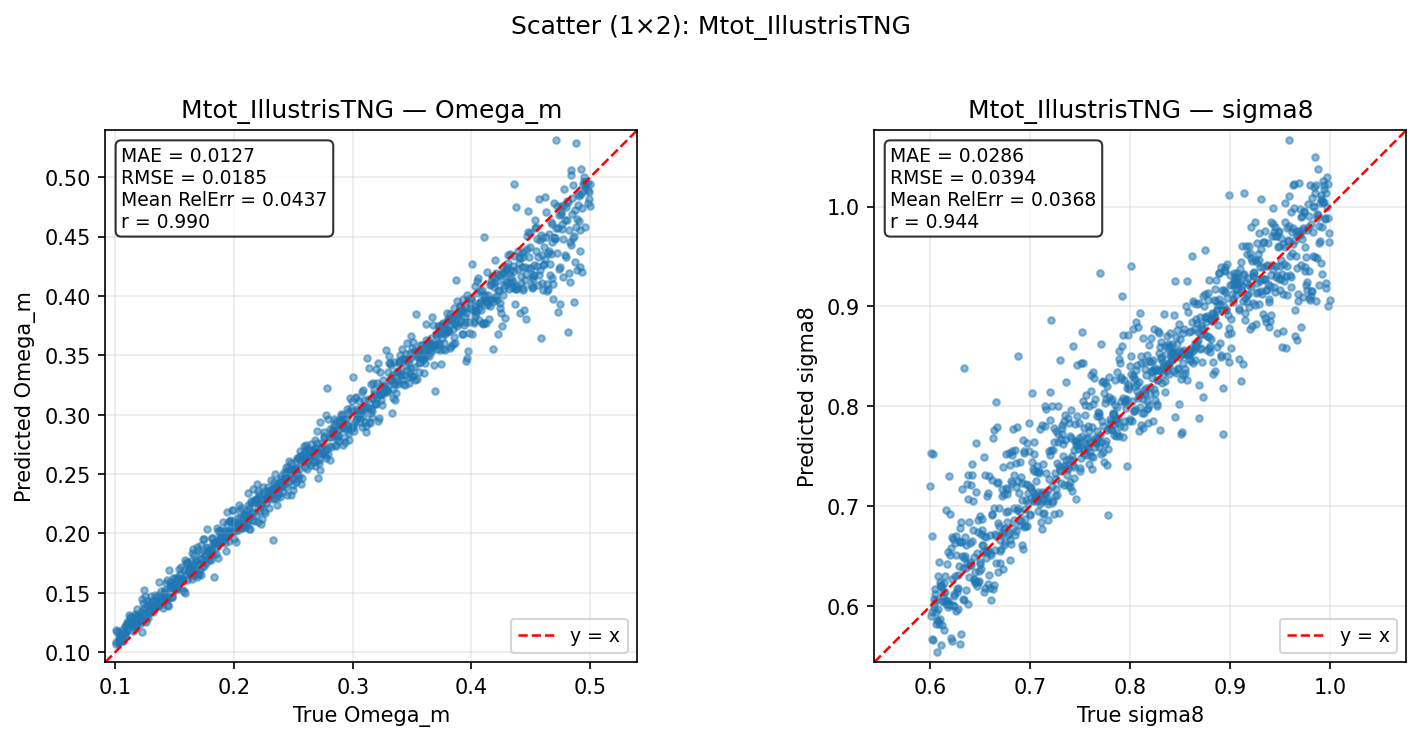

✅ 완료! 결과는 ./Mtot_Both_eval_results 에 저장되었습니다.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# 경로 설정
# --------------------------------
BASE_DIR = "/home/users/mmingyeong/250818_a3net/unet/predictions"
SIMS = ["Mtot_SIMBA", "Mtot_IllustrisTNG"]
RUNS_DIR = "/home/users/mmingyeong/250818_a3net/unet/runs/Mtot_Both/20250821_112245"

SAVE_DIR = "./Mtot_Both_eval_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# --------------------------------
# 유틸 함수
# --------------------------------
def load_predictions(pred_dir):
    true_path = os.path.join(pred_dir, "trues.npy")
    pred_path = os.path.join(pred_dir, "preds.npy")
    if not (os.path.exists(true_path) and os.path.exists(pred_path)):
        raise FileNotFoundError(f"Missing prediction files in {pred_dir}")
    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    return y_true, y_pred

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mean_rel_err(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))

# --------------------------------
# Loss curve (그대로 유지)
# --------------------------------
def plot_loss_curve(run_dir):
    log_path = os.path.join(run_dir, "training_log.csv")
    if not os.path.exists(log_path):
        print(f"⚠️ No training log found at {log_path}")
        return
    df = pd.read_csv(log_path)

    plt.figure(figsize=(6,4))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    if "val_loss" in df.columns:
        plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# --------------------------------
# 파라미터별 Scatter
# --------------------------------
def plot_scatter_per_param(y_true, y_pred, sim_name, param_names):
    """
    y_true, y_pred: (N, D) with D == len(param_names)
    각 파라미터별로 파일을 별도 저장.
    """
    for i, pname in enumerate(param_names):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        # 메트릭
        m_mae = mae(yt, yp)
        m_rmse = rmse(yt, yp)
        m_rel  = mean_rel_err(yt, yp)
        r = np.corrcoef(yt, yp)[0, 1] if len(yt) > 1 else np.nan

        # 축 범위(동일 스케일)
        lo = min(yt.min(), yp.min())
        hi = max(yt.max(), yp.max())
        pad = 0.02 * (hi - lo if hi > lo else 1.0)
        lo, hi = lo - pad, hi + pad

        plt.figure(figsize=(5.2, 5.2), dpi=150)
        plt.scatter(yt, yp, s=10, alpha=0.5)
        plt.plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="y = x")
        plt.xlim(lo, hi); plt.ylim(lo, hi)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.grid(alpha=0.25)

        plt.xlabel(f"True {pname}")
        plt.ylabel(f"Predicted {pname}")
        plt.title(f"Scatter: {sim_name} — {pname}")

        # 메트릭 박스
        txt = (f"MAE = {m_mae:.4f}\n"
               f"RMSE = {m_rmse:.4f}\n"
               f"Mean RelErr = {m_rel:.4f}\n"
               f"r = {r:.3f}")
        plt.text(0.03, 0.97, txt, transform=plt.gca().transAxes,
                 va="top", ha="left", fontsize=9,
                 bbox=dict(boxstyle="round", fc="w", alpha=0.8))

        plt.legend(loc="lower right", fontsize=9)
        out = os.path.join(SAVE_DIR, f"scatter_{sim_name}_{pname}.png")
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

# --------------------------------
# 파라미터 1×2 스캐터 (시뮬레이션별)
# --------------------------------
def plot_scatter_row(y_true, y_pred, sim_name, param_names):
    """
    y_true, y_pred: (N, D) with D == len(param_names)
    한 시뮬레이션에 대해 파라미터 2개(예: Ωm, σ8)를 1x2로 그려 저장.
    """
    D = len(param_names)
    fig, axes = plt.subplots(1, D, figsize=(10.5, 4.8), dpi=150)

    if D == 1:
        axes = [axes]

    for i, pname in enumerate(param_names):
        ax = axes[i]
        yt = y_true[:, i]
        yp = y_pred[:, i]

        # 메트릭
        m_mae  = np.mean(np.abs(yt - yp))
        m_rmse = np.sqrt(np.mean((yt - yp) ** 2))
        m_rel  = np.mean(np.abs((yt - yp) / (yt + 1e-8)))
        r = np.corrcoef(yt, yp)[0, 1] if len(yt) > 1 else np.nan

        # 축 범위(해당 파라미터에 대해 동일 스케일)
        lo = min(yt.min(), yp.min())
        hi = max(yt.max(), yp.max())
        pad = 0.02 * (hi - lo if hi > lo else 1.0)
        lo, hi = lo - pad, hi + pad

        # 플롯
        ax.scatter(yt, yp, s=10, alpha=0.5)
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="y = x")
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        ax.set_xlabel(f"True {pname}")
        ax.set_ylabel(f"Predicted {pname}")
        ax.set_title(f"{sim_name} — {pname}")

        # 메트릭 박스
        txt = (f"MAE = {m_mae:.4f}\n"
               f"RMSE = {m_rmse:.4f}\n"
               f"Mean RelErr = {m_rel:.4f}\n"
               f"r = {r:.3f}")
        ax.text(0.03, 0.97, txt, transform=ax.transAxes,
                va="top", ha="left", fontsize=9,
                bbox=dict(boxstyle="round", fc="w", alpha=0.8))

        ax.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f"scatter_row_{sim_name}.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

        
# --------------------------------
# 실행
# --------------------------------
if __name__ == "__main__":
    print("📊 Generating evaluation results...")

    # 원하는 파라미터 순서(예측 저장 순서와 일치해야 함)
    param_names = ["Omega_m", "sigma8"]

    # Loss curve
    plot_loss_curve(RUNS_DIR)

    # 각 시뮬레이션별 파라미터 scatter 저장
    # 각 시뮬레이션별 1×2 스캐터 저장
    for sim in SIMS:
        pred_dir = os.path.join(BASE_DIR, sim)
        y_true, y_pred = load_predictions(pred_dir)
        plot_scatter_row(y_true, y_pred, sim_name=sim, param_names=["Omega_m", "sigma8"])


    print(f"✅ 완료! 결과는 {SAVE_DIR} 에 저장되었습니다.")


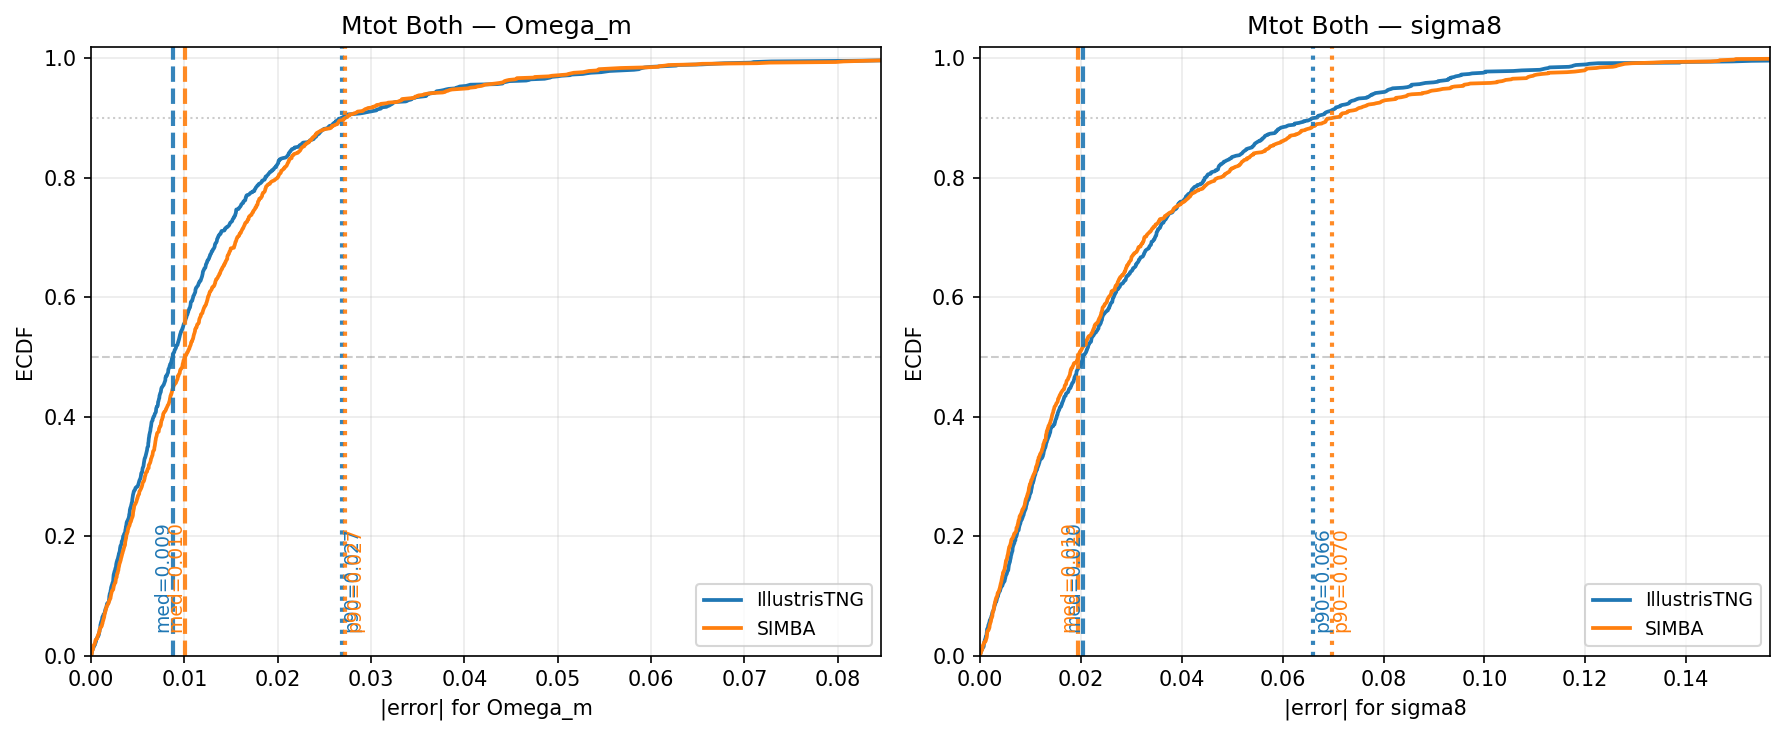

Saved summary stats → ./ecdf_summary.csv

     simulation    param    median       p90       MAE
0  IllustrisTNG  Omega_m  0.008740  0.026882  0.012700
1  IllustrisTNG   sigma8  0.020446  0.066023  0.028558
2         SIMBA  Omega_m  0.010055  0.027198  0.013471
3         SIMBA   sigma8  0.019477  0.069738  0.029146


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import OrderedDict

# -----------------------------
# 데이터 불러오기
# -----------------------------
def load_predictions(pred_dir):
    true_path = os.path.join(pred_dir, "trues.npy")
    pred_path = os.path.join(pred_dir, "preds.npy")
    if not (os.path.exists(true_path) and os.path.exists(pred_path)):
        raise FileNotFoundError(f"Missing npy in {pred_dir}")
    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    return y_true, y_pred

# -----------------------------
# ECDF & 에러 계산
# -----------------------------
def compute_ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

def compute_errors(y_true, y_pred, param_names):
    return {p: np.abs(y_true[:, i] - y_pred[:, i]) for i, p in enumerate(param_names)}

# -----------------------------
# 통계 요약 (median, p90, mae)
# -----------------------------
def summarize_errors(errors_dict, param_names):
    rows = []
    for sim_name, err_by_param in errors_dict.items():
        for p in param_names:
            e = err_by_param[p]
            rows.append({
                "simulation": sim_name,
                "param": p,
                "median": float(np.median(e)),
                "p90": float(np.quantile(e, 0.90)),
                "MAE": float(np.mean(e)),
            })
    return pd.DataFrame(rows)

# -----------------------------
# ECDF 플롯 (median & p90만 표시)
# -----------------------------
def plot_ecdf(errors_dict, param_names, title_prefix, savepath=None, summary_csv=None):
    fig, axes = plt.subplots(1, len(param_names), figsize=(12, 5), dpi=150)
    if len(param_names) == 1:
        axes = [axes]

    # 시뮬 이름 → 색상 고정
    color_map = OrderedDict({
        "IllustrisTNG": "tab:blue",
        "SIMBA": "tab:orange",
        # 필요 시 더 추가
    })
    # errors_dict에 없는 시뮬은 임의 색상
    for name in errors_dict.keys():
        if name not in color_map:
            color_map[name] = None  # matplotlib 기본 순환색

    # x축 범위(극단값 영향 줄이기 위해 99.5% 범위 사용)
    q995 = {p: max(np.quantile(errs[p], 0.995) for errs in errors_dict.values())
            for p in param_names}

    for ax, p in zip(axes, param_names):
        # ECDF 라인
        for sim_name, err_by_param in errors_dict.items():
            e = err_by_param[p]
            x, y = compute_ecdf(e)
            ax.plot(x, y, label=sim_name, color=color_map[sim_name], linewidth=1.8)

        # 수평 보조선 (50%, 90%)
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.4)
        ax.axhline(0.9, color="grey", linestyle=":", linewidth=1, alpha=0.4)

        # 수직선: median(— —), p90(· –)
        for sim_name, err_by_param in errors_dict.items():
            e = err_by_param[p]
            med = np.median(e)
            p90 = np.quantile(e, 0.90)

            c = color_map[sim_name]
            ax.axvline(med, color=c, linestyle="--", linewidth=2, alpha=0.9)
            ax.axvline(p90, color=c, linestyle=":", linewidth=2, alpha=0.9)

            # 선 옆에 값 주석(상단 가장자리 근처)
            ax.text(med, 0.04, f"med={med:.3f}", rotation=90, color=c,
                    va="bottom", ha="right", fontsize=9)
            ax.text(p90, 0.04, f"p90={p90:.3f}", rotation=90, color=c,
                    va="bottom", ha="left", fontsize=9)

        ax.set_xlim(0, q995[p]*1.05)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel(f"|error| for {p}")
        ax.set_ylabel("ECDF")
        ax.grid(alpha=0.25)
        ax.set_title(f"{title_prefix} — {p}")

        # 범례는 아래 한 곳만: 라인만 표시(세로선은 주석으로 표기하므로 지저분함 방지)
        ax.legend(loc="lower right", frameon=True, fontsize=9)

    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath) or ".", exist_ok=True)
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

    # 통계 요약 저장
    if summary_csv:
        df = summarize_errors(errors_dict, param_names)
        os.makedirs(os.path.dirname(summary_csv) or ".", exist_ok=True)
        df.to_csv(summary_csv, index=False)
        print(f"Saved summary stats → {summary_csv}\n")
        print(df)

# -----------------------------
# 실행
# -----------------------------
if __name__ == "__main__":
    # 경로
    pred_dir_tng = "./unet/predictions/Mtot_IllustrisTNG"
    pred_dir_simba = "./unet/predictions/Mtot_SIMBA"
    save_png = "./ecdf_comparison.png"
    save_csv = "./ecdf_summary.csv"

    # 파라미터 이름(라벨 순서와 일치)
    param_names = ["Omega_m", "sigma8"]

    # 불러오기
    y_true_tng, y_pred_tng = load_predictions(pred_dir_tng)
    y_true_simba, y_pred_simba = load_predictions(pred_dir_simba)

    # 에러
    errors_tng = compute_errors(y_true_tng, y_pred_tng, param_names)
    errors_simba = compute_errors(y_true_simba, y_pred_simba, param_names)

    errors_dict = OrderedDict([
        ("IllustrisTNG", errors_tng),
        ("SIMBA", errors_simba),
    ])

    # 플롯 + 요약 저장
    plot_ecdf(errors_dict, param_names, title_prefix="Mtot Both",
              savepath=save_png, summary_csv=save_csv)


In [7]:
import os
import re
import pandas as pd
import numpy as np
from datetime import datetime

# ---------------------------------------------------------------------
# 설정
# ---------------------------------------------------------------------
PRED_ROOT = "/home/users/mmingyeong/250818_a3net/unet/predictions"
CASES = [
    "case_1_SIMBA_Mtot_A", "case_2_SIMBA_Mtot_B", "case_3_SIMBA_Mtot_C",
    "case_4_TNG_Mtot_A",   "case_5_TNG_Mtot_B",   "case_6_TNG_Mtot_C",
    "case_7_SIMBA_P_A",    "case_8_SIMBA_P_B",    "case_9_SIMBA_P_C",
    "case_10_TNG_P_A",     "case_11_TNG_P_B",     "case_12_TNG_P_C",
]
SAVE_CSV = "./metrics_summary.csv"

# ---------------------------------------------------------------------
# 유틸
# ---------------------------------------------------------------------
TS_PAT = re.compile(r"^\d{8}_\d{6}$")

def latest_subdir(path: str) -> str:
    """path 아래 가장 최신(타임스탬프 형식 우선)의 하위 폴더를 반환."""
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Directory not found: {path}")
    subdirs = [d for d in os.listdir(path)
               if os.path.isdir(os.path.join(path, d))]
    if not subdirs:
        raise FileNotFoundError(f"No subdirectories in {path}")

    def sort_key(d):
        full = os.path.join(path, d)
        if TS_PAT.match(d):
            try:
                return datetime.strptime(d, "%Y%m%d_%H%M%S").timestamp()
            except Exception:
                pass
        return os.path.getmtime(full)

    latest = max(subdirs, key=sort_key)
    return os.path.join(path, latest)

def rel_err_stats(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """MAE와 상대오차(평균/중앙/90%) 계산."""
    err_abs = np.abs(y_pred - y_true)
    rel_abs = err_abs / (np.abs(y_true) + 1e-8)  # 0 나눗셈 방지
    return {
        "MAE": float(err_abs.mean()),
        "MeanRelErr": float(rel_abs.mean()),
        "MedianRelErr": float(np.median(rel_abs)),
        "P90RelErr": float(np.quantile(rel_abs, 0.90)),
        "N": int(len(y_true)),
    }

def load_predictions_csv(case_dir: str) -> pd.DataFrame:
    """case 폴더에서 최신 타임스탬프 하위폴더의 predictions.csv 로드."""
    latest_dir = latest_subdir(case_dir)
    csv_path = os.path.join(latest_dir, "predictions.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"predictions.csv not found: {csv_path}")
    return pd.read_csv(csv_path), csv_path

# ---------------------------------------------------------------------
# 본 처리
# ---------------------------------------------------------------------
rows = []

for case in CASES:
    case_dir = os.path.join(PRED_ROOT, case)
    try:
        df, src = load_predictions_csv(case_dir)
    except Exception as e:
        print(f"⚠️ Skip {case}: {e}")
        continue

    # 컬럼에서 파라미터명 자동 추출 (true_*, pred_* 쌍)
    true_cols = [c for c in df.columns if c.startswith("true_")]
    pred_cols = [c for c in df.columns if c.startswith("pred_")]
    params = sorted(set(c.replace("true_", "") for c in true_cols)
                    .intersection(c.replace("pred_", "") for c in pred_cols))
    if not params:
        print(f"⚠️ No true_/pred_ column pairs in {src}")
        continue

    # case 메타 파싱(선택)
    # 형식: case_k_SIM/ TNG _Field_Subset
    sim = field = subset = "NA"
    try:
        parts = case.split("_")
        # case, idx, SIMBA/TNG, Field, Subset
        sim, field, subset = parts[2], parts[3], parts[4]
    except Exception:
        pass

    for p in params:
        y_true = df[f"true_{p}"].to_numpy()
        y_pred = df[f"pred_{p}"].to_numpy()
        stats = rel_err_stats(y_true, y_pred)
        rows.append({
            "case": case,
            "simulation": sim,
            "field": field,
            "subset": subset,
            "param": p,
            "MAE": stats["MAE"],
            "MeanRelErr": stats["MeanRelErr"],
            "MedianRelErr": stats["MedianRelErr"],
            "P90RelErr": stats["P90RelErr"],
            "N": stats["N"],
            "source": src,
        })

# 요약 테이블
summary = pd.DataFrame(rows)
# 퍼센트 컬럼도 추가(가독성용)
for c in ["MeanRelErr", "MedianRelErr", "P90RelErr"]:
    summary[c + "(%)"] = summary[c] * 100.0

# 보기 좋게 정렬
summary = summary.sort_values(["case", "param"]).reset_index(drop=True)

# 출력 및 저장
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 120)
print(summary[["case", "param", "MAE", "MeanRelErr(%)", "MedianRelErr(%)", "P90RelErr(%)", "N", "source"]])

summary.to_csv(SAVE_CSV, index=False)
print(f"\n✅ Saved table → {SAVE_CSV}")


                   case    param       MAE  MeanRelErr(%)  MedianRelErr(%)  \
0       case_10_TNG_P_A  Omega_m  0.085937      27.754093        24.483826   
1       case_10_TNG_P_A  sigma_8  0.103671      13.169121        11.555568   
2       case_11_TNG_P_B     AGN1  0.086610      27.535017        25.054338   
3       case_11_TNG_P_B     AGN2  0.100893      13.209281        10.626506   
4       case_12_TNG_P_C      SN1  0.081729      26.182114        23.021869   
5       case_12_TNG_P_C      SN2  0.101125      13.203796        10.803208   
6   case_1_SIMBA_Mtot_A  Omega_m  0.017094       7.303806         4.592808   
7   case_1_SIMBA_Mtot_A  sigma_8  0.034552       4.326585         3.112677   
8   case_2_SIMBA_Mtot_B     AGN1  0.029598       9.719475         9.043879   
9   case_2_SIMBA_Mtot_B     AGN2  0.036222       4.555041         3.250436   
10  case_3_SIMBA_Mtot_C      SN1  0.021403       7.326625         6.485003   
11  case_3_SIMBA_Mtot_C      SN2  0.038441       4.881485       

In [12]:
# ... (everything above unchanged)

# Summary table
summary = pd.DataFrame(rows)
for c in ["MeanRelErr", "MedianRelErr", "P90RelErr"]:
    summary[c + "(%)"] = summary[c] * 100.0

# Default view (sorted by case, param)
summary = summary.sort_values(["case", "param"]).reset_index(drop=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 120)
print("=== Summary (sorted by case, param) ===")
print(summary[["case","param","MAE","MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","source"]])

summary.to_csv(SAVE_CSV, index=False)
print(f"\n✅ Saved table → {SAVE_CSV}")

# ------------------------------
# Also: MAE-sorted view
# ------------------------------
summary_by_mae = summary.sort_values(["MAE","case","param"]).reset_index(drop=True)
print("\n=== Summary (sorted by MAE ↑) ===")
print(summary_by_mae[["case","param","MAE","MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","source"]])
summary_by_mae.to_csv(SAVE_CSV.replace(".csv","_byMAE.csv"), index=False)
print(f"✅ Saved MAE-sorted table → {SAVE_CSV.replace('.csv','_byMAE.csv')}")

# ------------------------------
# Preferred: Relative-error-sorted view
# Pick one: 'mean', 'median', or 'p90'
# ------------------------------
REL_METRIC = "median"  # options: 'mean' | 'median' | 'p90'
REL_MAP = {"mean": "MeanRelErr", "median": "MedianRelErr", "p90": "P90RelErr"}
rel_col = REL_MAP[REL_METRIC]

summary_by_rel = summary.sort_values([rel_col, "case", "param"]).reset_index(drop=True)
print(f"\n=== Summary (sorted by {rel_col} ↑) ===")
print(summary_by_rel[["case","param","MAE","MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","source"]])

out_rel = SAVE_CSV.replace(".csv", f"_by{rel_col}.csv")
summary_by_rel.to_csv(out_rel, index=False)
print(f"✅ Saved relative-error-sorted table → {out_rel}")


=== Summary (sorted by case, param) ===
                   case    param       MAE  MeanRelErr(%)  MedianRelErr(%)  \
0       case_10_TNG_P_A  Omega_m  0.085937      27.754093        24.483826   
1       case_10_TNG_P_A  sigma_8  0.103671      13.169121        11.555568   
2       case_11_TNG_P_B     AGN1  0.086610      27.535017        25.054338   
3       case_11_TNG_P_B     AGN2  0.100893      13.209281        10.626506   
4       case_12_TNG_P_C      SN1  0.081729      26.182114        23.021869   
5       case_12_TNG_P_C      SN2  0.101125      13.203796        10.803208   
6   case_1_SIMBA_Mtot_A  Omega_m  0.017094       7.303806         4.592808   
7   case_1_SIMBA_Mtot_A  sigma_8  0.034552       4.326585         3.112677   
8   case_2_SIMBA_Mtot_B     AGN1  0.029598       9.719475         9.043879   
9   case_2_SIMBA_Mtot_B     AGN2  0.036222       4.555041         3.250436   
10  case_3_SIMBA_Mtot_C      SN1  0.021403       7.326625         6.485003   
11  case_3_SIMBA_Mtot_C 

In [13]:
import os
import re
import glob
import pandas as pd
import numpy as np
from datetime import datetime

# =============================================================
# Configuration
# =============================================================
BASE = "/home/users/mmingyeong/250818_a3net/unet"
PRED_ROOT = f"{BASE}/predictions"
CROSS_DIR  = f"{BASE}/cross_simul"

# Sources
SINGLE = {
    "Single_SIMBA_case1": os.path.join(PRED_ROOT, "case_1_SIMBA_Mtot_A"),
    "Single_TNG_case4":   os.path.join(PRED_ROOT, "case_4_TNG_Mtot_A"),
}
CROSS = {
    "Cross_SIMBA→TNG": os.path.join(CROSS_DIR, "cross_SIMBA_to_TNG.csv"),
    "Cross_TNG→SIMBA": os.path.join(CROSS_DIR, "cross_TNG_to_SIMBA.csv"),
}
MULTI = {
    "Multi_Mtot_IllustrisTNG": os.path.join(PRED_ROOT, "Mtot_IllustrisTNG"),
    "Multi_Mtot_SIMBA":        os.path.join(PRED_ROOT, "Mtot_SIMBA"),
}

SAVE_PREFIX = "./metrics_summary_6cases"  # will create multiple CSVs with this prefix

# =============================================================
# Utilities
# =============================================================
TS_PAT = re.compile(r"^\d{8}_\d{6}$")

def latest_subdir(path: str) -> str:
    """Return the most recent subdirectory under `path`.
    If a subdir name matches YYYYMMDD_HHMMSS, prefer its timestamp; otherwise use mtime.
    """
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Directory not found: {path}")
    subs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    if not subs:
        raise FileNotFoundError(f"No subdirectories in {path}")

    def sort_key(d):
        full = os.path.join(path, d)
        if TS_PAT.match(d):
            try:
                return datetime.strptime(d, "%Y%m%d_%H%M%S").timestamp()
            except Exception:
                pass
        return os.path.getmtime(full)

    latest = max(subs, key=sort_key)
    return os.path.join(path, latest)

def find_predictions_csv(path_like: str) -> str:
    """Resolve `path_like` to a concrete predictions.csv path.
    - If `path_like` is a CSV file, return it.
    - If `path_like` is a directory:
        1) If it has timestamped subdirs, use latest_subdir(...)/predictions.csv
        2) Else if `<dir>/predictions.csv` exists, use it
        3) Else search recursively for '**/predictions.csv' and pick the most recent
    """
    if os.path.isfile(path_like) and path_like.endswith(".csv"):
        return path_like
    if not os.path.isdir(path_like):
        raise FileNotFoundError(f"Path not found: {path_like}")

    # Strategy 1: timestamped subdir
    try:
        sub = latest_subdir(path_like)
        cand = os.path.join(sub, "predictions.csv")
        if os.path.isfile(cand):
            return cand
    except Exception:
        pass

    # Strategy 2: direct file in dir
    cand = os.path.join(path_like, "predictions.csv")
    if os.path.isfile(cand):
        return cand

    # Strategy 3: recursive search
    cands = glob.glob(os.path.join(path_like, "**", "predictions.csv"), recursive=True)
    if cands:
        cands.sort(key=os.path.getmtime, reverse=True)
        return cands[0]

    raise FileNotFoundError(f"predictions.csv not found under: {path_like}")

def load_predictions(path_like: str) -> tuple[pd.DataFrame, str]:
    """Load a predictions CSV from file or directory."""
    csv_path = find_predictions_csv(path_like)
    return pd.read_csv(csv_path), csv_path

def rel_err_stats(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> dict:
    """Compute MAE and robust relative-error summaries."""
    err_abs = np.abs(y_pred - y_true)
    rel_abs = err_abs / (np.abs(y_true) + eps)
    return {
        "MAE": float(err_abs.mean()),
        "MeanRelErr": float(rel_abs.mean()),
        "MedianRelErr": float(np.median(rel_abs)),
        "P90RelErr": float(np.quantile(rel_abs, 0.90)),
        "N": int(len(y_true)),
    }

def params_from_df(df: pd.DataFrame) -> list[str]:
    """Identify parameter names from 'true_*' and 'pred_*' column pairs."""
    tcols = {c.replace("true_", "") for c in df.columns if c.startswith("true_")}
    pcols = {c.replace("pred_", "") for c in df.columns if c.startswith("pred_")}
    params = sorted(tcols.intersection(pcols))
    return params

# =============================================================
# Main aggregation
# =============================================================
rows = []

def process_group(group_name: str, mapping: dict, category: str):
    for label, path in mapping.items():
        try:
            df, src = load_predictions(path)
        except Exception as e:
            print(f"⚠️ Skip {label} ({category}): {e}")
            continue

        params = params_from_df(df)
        if not params:
            print(f"⚠️ No true_/pred_ pairs in {src}")
            continue

        for p in params:
            y_true = df[f"true_{p}"].to_numpy()
            y_pred = df[f"pred_{p}"].to_numpy()
            stats = rel_err_stats(y_true, y_pred)
            rows.append({
                "category": category,       # Single / Cross / Multi
                "source":   label,          # human-readable label
                "param":    p,
                "MAE":          stats["MAE"],
                "MeanRelErr":   stats["MeanRelErr"],
                "MedianRelErr": stats["MedianRelErr"],
                "P90RelErr":    stats["P90RelErr"],
                "N":            stats["N"],
                "file":         src,
            })

process_group("SINGLE", SINGLE, category="Single")
process_group("CROSS",  CROSS,  category="Cross")
process_group("MULTI",  MULTI,  category="Multi")

summary = pd.DataFrame(rows)
if summary.empty:
    raise RuntimeError("No rows collected. Check paths and file formats.")

# Add percentage columns for readability
for c in ["MeanRelErr", "MedianRelErr", "P90RelErr"]:
    summary[c + "(%)"] = summary[c] * 100.0

# -------------------------------------------------------------
# Print & Save: canonical view (by category, source, param)
# -------------------------------------------------------------
summary_std = summary.sort_values(["category", "source", "param"]).reset_index(drop=True)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 140)

print("=== Summary (by category, source, param) ===")
print(summary_std[[
    "category","source","param","MAE",
    "MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","file"
]])

out_std = f"{SAVE_PREFIX}.csv"
summary_std.to_csv(out_std, index=False)
print(f"\n✅ Saved → {out_std}")

# -------------------------------------------------------------
# Print & Save: MAE-sorted (secondary view)
# -------------------------------------------------------------
summary_mae = summary.sort_values(["MAE","category","source","param"]).reset_index(drop=True)
print("\n=== Summary (sorted by MAE ↑) ===")
print(summary_mae[[
    "category","source","param","MAE",
    "MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","file"
]])

out_mae = f"{SAVE_PREFIX}_byMAE.csv"
summary_mae.to_csv(out_mae, index=False)
print(f"✅ Saved → {out_mae}")

# -------------------------------------------------------------
# Print & Save: Relative-error–sorted (preferred)
# Choose 'MeanRelErr', 'MedianRelErr', or 'P90RelErr'
# -------------------------------------------------------------
REL_COL = "MedianRelErr"  # robust choice
summary_rel = summary.sort_values([REL_COL, "category", "source", "param"]).reset_index(drop=True)

print(f"\n=== Summary (sorted by {REL_COL} ↑) ===")
print(summary_rel[[
    "category","source","param","MAE",
    "MeanRelErr(%)","MedianRelErr(%)","P90RelErr(%)","N","file"
]])

out_rel = f"{SAVE_PREFIX}_by{REL_COL}.csv"
summary_rel.to_csv(out_rel, index=False)
print(f"✅ Saved → {out_rel}")


=== Summary (by category, source, param) ===
   category                   source    param       MAE  MeanRelErr(%)  \
0     Cross          Cross_SIMBA→TNG  Omega_m  0.020911       8.159659   
1     Cross          Cross_SIMBA→TNG   sigma8  0.051296       6.665642   
2     Cross          Cross_TNG→SIMBA  Omega_m  0.036041      10.836201   
3     Cross          Cross_TNG→SIMBA   sigma8  0.063905       7.781336   
4     Multi  Multi_Mtot_IllustrisTNG  Omega_m  0.012700       4.370488   
5     Multi  Multi_Mtot_IllustrisTNG  sigma_8  0.028558       3.684009   
6     Multi         Multi_Mtot_SIMBA  Omega_m  0.013471       4.950008   
7     Multi         Multi_Mtot_SIMBA  sigma_8  0.029146       3.653294   
8    Single       Single_SIMBA_case1  Omega_m  0.017094       7.303766   
9    Single       Single_SIMBA_case1  sigma_8  0.034552       4.326579   
10   Single         Single_TNG_case4  Omega_m  0.035266      10.534551   
11   Single         Single_TNG_case4  sigma_8  0.039382       4.868